In [ ]:
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt
from shapely import LineString

marker_dict = json.load(open("markers.json", "r"))
size_from_marker = {
    "aruco": (5, 5),
    "4x4_1000": (4, 4),
    "5x5_1000": (5, 5),
    "6x6_1000": (6, 6),
    "7x7_1000": (7, 7),
    "mip_36h12": (6, 6),
    "april_16h5": (4, 4),
    "april_25h9": (5, 5),
    "april_36h10": (6, 6),
    "april_36h11": (6, 6),
}

def arucoMatrix(dictName, id):
    width, height = size_from_marker[dictName]
    bytes_ = marker_dict[dictName][id]
    bits = []
    bitsCount = width * height

    if bytes_ is None:
        print(f"{dictName} does not have id {id}")
        bits = [0] * bitsCount
        return bits

    # Parse marker's bytes
    for byte in bytes_:
        start = bitsCount - len(bits)
        for i in range(min(7, start - 1), -1, -1):
            bits.append((byte >> i) & 1)
    return bits, width

def first_pixel(marker):
    for i in range(marker.shape[0]):
        for j in range(marker.shape[1]):
            if marker[i,j] == 1:
                return (j,i)
    return None

def build_contour(marker):
    coord_to_pixel = lambda x, y: np.array([int(y), int(x)], dtype=np.int32)
    contour = []
    first = first_pixel(marker)
    if first is None:
        return contour
    contour.append(first)
    current = first
    direction = np.array([1, 0], dtype=np.int32)  # Start moving right
    while True:
        current = (current[0] + direction[0], current[1] + direction[1])
        debug_linestring = LineString(contour + [current])
        rel_dir_left = np.array([direction[1], -direction[0]])
        rel_dir_left_half_pix = (rel_dir_left + direction) * 0.5
        rel_dir_right = np.array([-direction[1], direction[0]])
        rel_dir_right_half_pix = (rel_dir_right + direction) * 0.5
        relative_left_pixel = 0
        relative_right_pixel = 0
        if 0 <= rel_dir_left_half_pix[0] + current[0] < marker.shape[0] and 0 <= rel_dir_left_half_pix[1] + current[1] < marker.shape[1]:
            next_pos = coord_to_pixel(rel_dir_left_half_pix[0] + current[0], rel_dir_left_half_pix[1] + current[1])
            relative_left_pixel = marker[next_pos[0], next_pos[1]]
        if 0 <= rel_dir_right_half_pix[0] + current[0] < marker.shape[0] and 0 <= rel_dir_right_half_pix[1] + current[1] < marker.shape[1]:
            next_pos = coord_to_pixel(rel_dir_right_half_pix[0] + current[0], rel_dir_right_half_pix[1] + current[1])
            relative_right_pixel = marker[next_pos[0], next_pos[1]]
        if relative_left_pixel == 0 and relative_right_pixel == 0:
            direction = rel_dir_right
        elif relative_left_pixel == 1:
            direction = rel_dir_left
        contour.append(current)
        if len(contour) > 2 and (contour[-1][0] == contour[-2][0] and contour[-3][0] == contour[-2][0] or contour[-1][1] == contour[-2][1] and contour[-3][1] == contour[-2][1]):
            contour.pop(-2)

        if current == first:
            break
    return contour

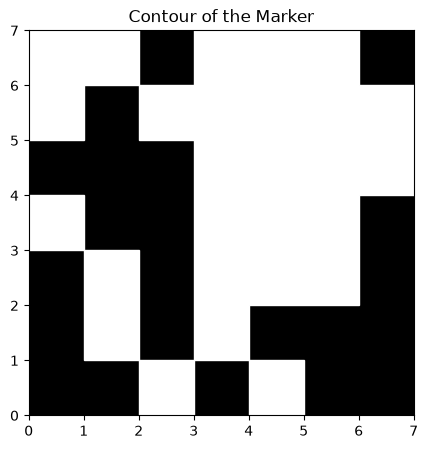

In [60]:
bits, size = arucoMatrix("7x7_1000", 0)
marker = np.array(bits, dtype=np.uint8).reshape(size, size)
contour = build_contour(marker)
contour = np.array(contour, dtype=np.int32)
svg = LineString(contour)
plt.figure(figsize=(5, 5))
plt.fill(svg.xy[0], np.array(marker.shape[0]) - svg.xy[1], color="white")
plt.gca().set_facecolor("black")
plt.xlim(0, marker.shape[1])
plt.ylim(0, marker.shape[0])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Contour of the Marker')
plt.show()